In [21]:
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
normalized_temperature = pd.read_csv("../results/norm_temp/norm_temp.tsv", sep="\t")
temperatures = normalized_temperature["normalised_temperature"].to_list()


In [3]:
counts, bin_edges = np.histogram(temperatures, bins=50)


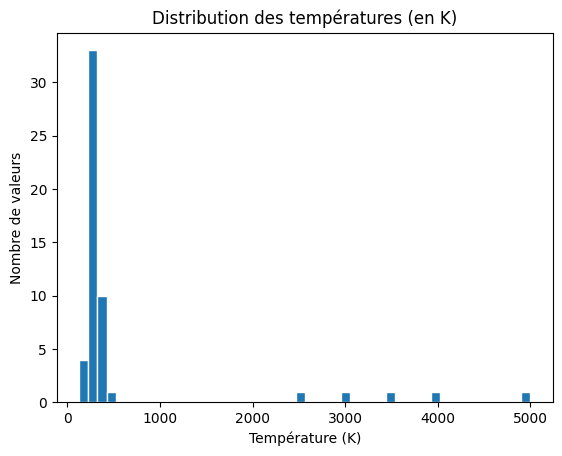

In [4]:
plt.hist(temperatures, bins=50, edgecolor="white")
plt.title("Distribution des températures (en K)")
plt.xlabel("Température (K)")
plt.ylabel("Nombre de valeurs")
plt.show()

In [14]:
with open("../data/STIME_ground_truth.json") as f:
    data = json.load(f)

In [15]:
time_to_ns = {
    "fs": 1e-6,
    "ps": 1e-3,
    "ns": 1,
    "μs": 1e3,
    "ms": 1e6,
    "s": 1e9,
    "ks": 1e12,
}

In [ ]:
valid_ns = []

for entry in data["groundtruth"]:
    output = entry["output"][0]

    if "value" in output and output["value"] is not None:
        has_value = True
    else:
        has_value = False
    if "unit" in output and output["unit"] is not None:
        has_unit = True
    else:
        has_unit = False

    if not has_value or not has_unit:
        print(f"Excluded (missing field): {entry['input']}")
        continue

    unit = output["unit"].strip().lower()

    if unit not in time_to_ns:
        print(f"Excluded (not a time unit): {entry['input']}  ")
        continue

    # Convert to nanoseconds
    value_ns = output["value"] * time_to_ns[unit]
    valid_ns.append(value_ns)
    print(f"Kept: {entry['input']}  ->  {output['value']} {unit}  =  {value_ns} ns")

print(f"\nTotal kept: {len(valid_ns)} values")

Kept: 500ns  ->  500 ns  =  500 ns
Kept: 100ns  ->  100 ns  =  100 ns
Kept: 200 ns  ->  200 ns  =  200 ns
Excluded (missing field): microsecond
Kept: 500 ns  ->  500 ns  =  500 ns
Kept: 1 microsecond  ->  1 μs  =  1000.0 ns
Kept: 200ns  ->  200 ns  =  200 ns
Kept: 100 ns  ->  100 ns  =  100 ns
Kept: 110 ns  ->  110 ns  =  110 ns
Kept: 1500 ns  ->  1500 ns  =  1500 ns
Kept: 300 ns  ->  300 ns  =  300 ns
Excluded (missing field): 315.0 k
Kept: 1 μs  ->  1 μs  =  1000.0 ns
Kept: 10 microseconds  ->  10 μs  =  10000.0 ns
Kept: 1000 ns  ->  1000 ns  =  1000 ns
Kept: 2 microseconds  ->  2 μs  =  2000.0 ns
Kept: 250 ns  ->  250 ns  =  250 ns
Kept: 3.0 us  ->  3.0 μs  =  3000.0 ns
Excluded (missing field): 317.0 k
Excluded (missing field): 319.1 meters
Kept: 5 μs  ->  5 μs  =  5000.0 ns
Kept: 50 ns  ->  50 ns  =  50 ns
Kept: 550ns  ->  550 ns  =  550 ns
Kept: 700ns  ->  700 ns  =  700 ns
Excluded (missing field): us
Kept: 0.5 μs  ->  0.5 μs  =  500.0 ns
Excluded (missing field): 0.6
Kept: 0.63

In [32]:
print(f"Valid time values (in ns): {len(valid_ns)}")

Valid time values (in ns): 87


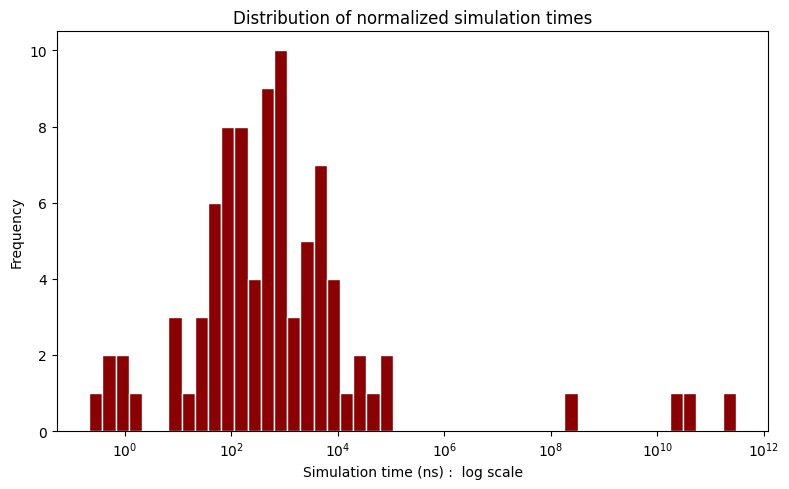

Chart saved as histogram.png


In [42]:
if len(valid_ns) == 0:
    print("No valid time values found — nothing to plot.")
else:
    bins = np.logspace(np.log10(min(valid_ns)), np.log10(max(valid_ns)), num=50)

    plt.figure(figsize=(8, 5))
    plt.hist(valid_ns, bins=bins, color="darkred", edgecolor="white")
    plt.xscale("log")
    plt.xlabel("Simulation time (ns) :  log scale")
    plt.ylabel("Frequency")
    plt.title("Distribution of normalized simulation times")
    plt.tight_layout()
    plt.savefig("histogram.png")
    plt.show()
    print("Chart saved as histogram.png")

In [25]:
UNITS_TO_NS = {
    "fs": 1e-6,
    "ps": 1e-3,
    "ns": 1,
    "μs": 1e3,
    "us": 1e3,
    "ms": 1e6,
    "s": 1e9,
}

pattern = re.compile(r"([0-9]+\.?[0-9]*)\s*(fs|ps|ns|μs|us|ms|s)")


In [26]:
with open("../data/STIME_ground_truth.json") as f:
    data = json.load(f)


In [27]:
values_ns = []
for entry in data["groundtruth"]:
    match = pattern.search(entry["input"])
    if match:
        values_ns.append(float(match.group(1)) * UNITS_TO_NS[match.group(2)])


In [33]:
print(len(values_ns))

60


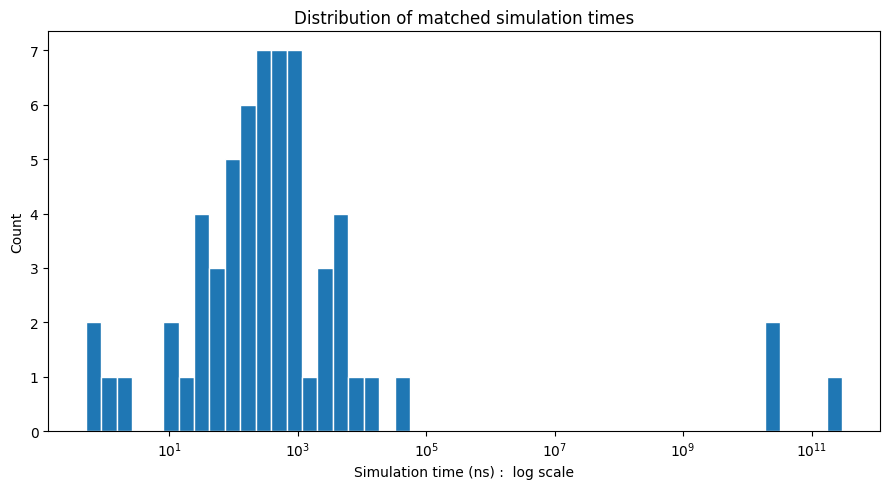

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    values_ns,
    bins=np.logspace(np.log10(min(values_ns)), np.log10(max(values_ns)), 50),
    edgecolor="white",
)
ax.set_xscale("log")
plt.xlabel("Simulation time (ns) :  log scale")
ax.set_ylabel("Count")
ax.set_title("Distribution of matched simulation times")
plt.tight_layout()
plt.savefig("stime_distribution.png")